Importing Libraries

In [7]:
print("Hello")

Hello


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load and Merging of the dataset

In [9]:
training_transx = pd.read_csv(r"D:\Fraud-Detection\data\raw\train_transaction.csv")
training_transx.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
training_id = pd.read_csv(r"D:\Fraud-Detection\data\raw\train_identity.csv")
training_id.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [11]:
df = training_transx.merge(training_id , on = "TransactionID" , how = "left")

In [12]:
print(f"Transacation Table : {training_transx.shape}")
print(f"Identity Table : {training_id.shape}")
print(f"Merged Table : {df.shape}")

Transacation Table : (590540, 394)
Identity Table : (144233, 41)
Merged Table : (590540, 434)


Checking for Imbalance

In [13]:
print(f"Fraud Rate : {df["isFraud"].mean()*100:.2f} %")
print(f"Total Number of Fraud Cases : {(df["isFraud"] == 1).sum()}")
print(f"Total Number of Clean Cases : {(df["isFraud"] == 0).sum()}")

Fraud Rate : 3.50 %
Total Number of Fraud Cases : 20663
Total Number of Clean Cases : 569877


Checking for Missing Values

In [14]:
missing = df.isnull().mean().sort_values(ascending = False)
missing_greater_50 = missing[missing > 0.5]
print(missing_greater_50)
print(f"\n Number of columns with more than 50 percent missing values : {len(missing_greater_50)}")

id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
           ...   
M5       0.593494
M7       0.586353
M9       0.586331
M8       0.586331
D5       0.524674
Length: 214, dtype: float64

 Number of columns with more than 50 percent missing values : 214


In [15]:
print("Non-fraud amount stats:")
print(df[df['isFraud']==0]['TransactionAmt'].describe())
print("\nFraud amount stats:")
print(df[df['isFraud']==1]['TransactionAmt'].describe())

Non-fraud amount stats:
count    569877.000000
mean        134.511665
std         239.395078
min           0.251000
25%          43.970000
50%          68.500000
75%         120.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

Fraud amount stats:
count    20663.000000
mean       149.244779
std        232.212163
min          0.292000
25%         35.044000
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64


Class Distribution Plots (Count and Proportions)

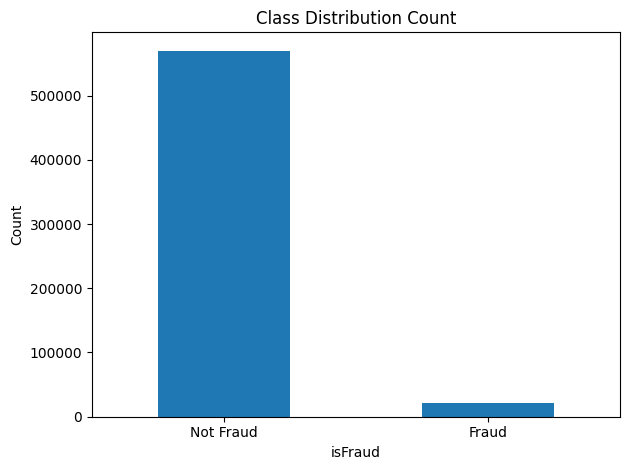

In [16]:
#Count
fig = df['isFraud'].value_counts().plot(kind = 'bar')
fig.set_title("Class Distribution Count")
fig.set_xticklabels(['Not Fraud', 'Fraud'], rotation=0)
plt.ylabel("Count")

plt.savefig('../reports/class_distribution.png', dpi=150)

plt.tight_layout()
plt.show()

Transaction Amount Analysis

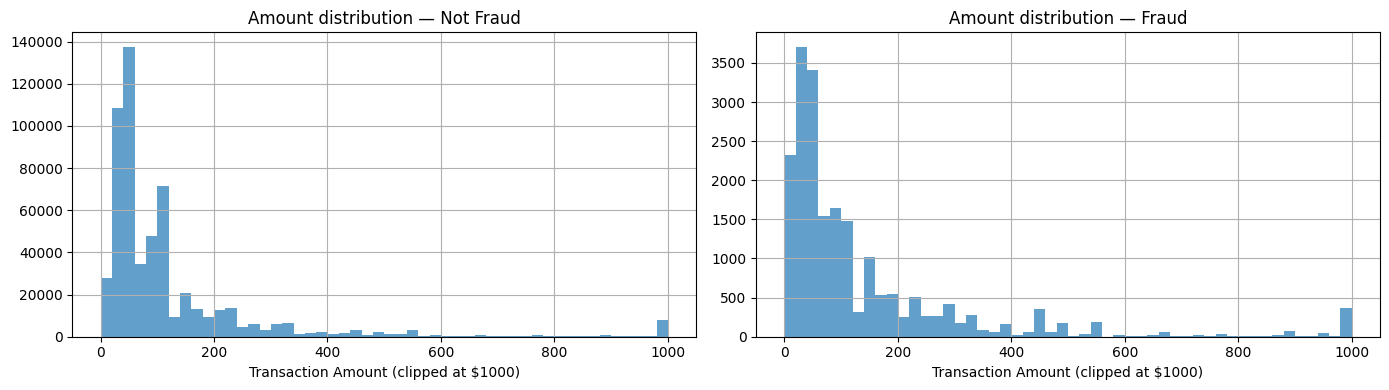

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['isFraud']==0]['TransactionAmt'].clip(upper=1000).hist(bins=50, ax=axes[0], alpha=0.7)
axes[0].set_title('Amount distribution — Not Fraud')
axes[0].set_xlabel('Transaction Amount (clipped at $1000)')

df[df['isFraud']==1]['TransactionAmt'].clip(upper=1000).hist(bins=50, ax=axes[1], alpha=0.7)
axes[1].set_title('Amount distribution — Fraud')
axes[1].set_xlabel('Transaction Amount (clipped at $1000)')

plt.savefig('../reports/Transaction_Amount_Distribution.png', dpi=150)

plt.tight_layout()
plt.show()

Transaction Hour Analysis

In [18]:
df['Transaction_hour'] = (df['TransactionDT'] / 3600) % 24

In [19]:
print('Distribution of transaction time for Non Fraud Class :')
print(df[df['isFraud'] == 0]['Transaction_hour'].describe())
print('\n Distribution of transaction time for Fraud Class : ')
print(df[df['isFraud'] == 1]['Transaction_hour'].describe())

Distribution of transaction time for Non Fraud Class :
count    569877.000000
mean         14.382553
std           7.612618
min           0.000000
25%           6.936389
50%          16.846111
75%          20.410556
max          23.999722
Name: Transaction_hour, dtype: float64

 Distribution of transaction time for Fraud Class : 
count    20663.000000
mean        13.837575
std          7.770199
min          0.000556
25%          5.514583
50%         16.656667
75%         20.369861
max         23.999722
Name: Transaction_hour, dtype: float64


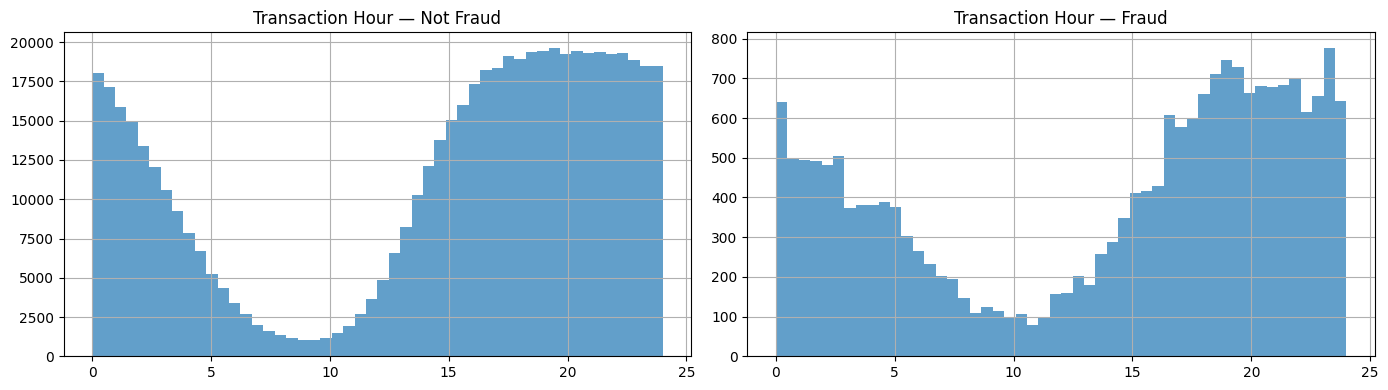

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['isFraud']==0]['Transaction_hour'].clip(upper=1000).hist(bins=50, ax=axes[0], alpha=0.7)
axes[0].set_title('Transaction Hour — Not Fraud')

df[df['isFraud']==1]['Transaction_hour'].clip(upper=1000).hist(bins=50, ax=axes[1], alpha=0.7)
axes[1].set_title('Transaction Hour — Fraud')

plt.savefig('../reports/Transaction_Time_Distribution.png', dpi=150)

plt.tight_layout()
plt.show()

Exploring the Categorical Columns

In [21]:
df.dtypes[df.dtypes == 'object']

ProductCD        object
card4            object
card6            object
P_emaildomain    object
R_emaildomain    object
M1               object
M2               object
M3               object
M4               object
M5               object
M6               object
M7               object
M8               object
M9               object
id_12            object
id_15            object
id_16            object
id_23            object
id_27            object
id_28            object
id_29            object
id_30            object
id_31            object
id_33            object
id_34            object
id_35            object
id_36            object
id_37            object
id_38            object
DeviceType       object
DeviceInfo       object
dtype: object

In [22]:
categorical_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']
for col in categorical_cols:
    fraud_rate = df.groupby(col)['isFraud'].mean().sort_values(ascending = False)
    print(f"\n --- {col} fraud rates -- ")
    print(fraud_rate.head(10))


 --- ProductCD fraud rates -- 
ProductCD
C    0.116873
S    0.058996
H    0.047662
R    0.037826
W    0.020399
Name: isFraud, dtype: float64

 --- card4 fraud rates -- 
card4
discover            0.077282
visa                0.034756
mastercard          0.034331
american express    0.028698
Name: isFraud, dtype: float64

 --- card6 fraud rates -- 
card6
credit             0.066785
debit              0.024263
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64

 --- P_emaildomain fraud rates -- 
P_emaildomain
protonmail.com    0.407895
mail.com          0.189624
outlook.es        0.130137
aim.com           0.126984
outlook.com       0.094584
hotmail.es        0.065574
live.com.mx       0.054740
hotmail.com       0.052950
gmail.com         0.043542
yahoo.fr          0.034965
Name: isFraud, dtype: float64

 --- R_emaildomain fraud rates -- 
R_emaildomain
protonmail.com    0.951220
mail.com          0.377049
netzero.net       0.222222
outlook.com       0.1

In [28]:
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("fraud-detection-eda")

with mlflow.start_run(run_name="dataset_statistics"):
    mlflow.log_metric("total_rows", len(df))
    mlflow.log_metric("fraud_rate", df['isFraud'].mean())
    mlflow.log_metric("fraud_count", int(df['isFraud'].sum()))
    mlflow.log_metric("feature_count", df.shape[1])
    mlflow.log_metric("high_missing_cols", len(missing_greater_50))
    
    mlflow.log_artifact('../reports/class_distribution.png')
    mlflow.log_artifact('../reports/Transaction_Amount_Distribution.png')
    mlflow.log_artifact('../reports/Transaction_Time_Distribution.png')

print("Logged to MLflow")

Logged to MLflow
